In [1]:
import pickle
import numpy as np
import pandas as pd
import os
from copy import deepcopy
from pathlib import Path
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.animation

import sys
# sys.path.append('..')
sys.path.append('../')
current_dir = os.getcwd()
import pypolo2

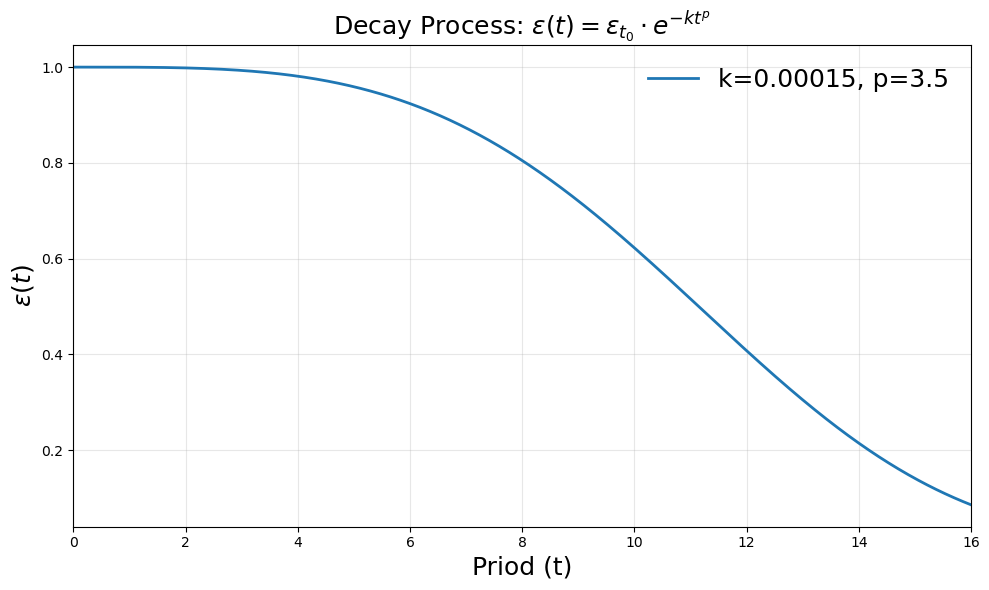

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# =====================
# 参数配置区 (按需修改)
# =====================
epsilon_t0 = 1.0    # 初始值 ε_{t0}
k_values = 0.00015  # 衰减系数k的多个取值
p_values = 3.5  # 幂指数p的多个取值
t_max = 16.0         # 时间范围 [0, t_max]
num_points = 1000   # 数据点密度

# =====================
# 函数定义
# =====================
def epsilon(t, epsilon_t0, k, p):
    """计算随时间衰减的因子值"""
    return epsilon_t0 * np.exp(-k * (t ** p))

# =====================
# 生成数据
# =====================
t = np.linspace(0, t_max, num_points)

plt.figure(figsize=(10, 6), dpi=100)
plt.title(r"Decay Process: $\varepsilon(t) = \varepsilon_{t_0} \cdot e^{-k t^p}$", fontsize=18)
plt.xlabel("Priod (t)", fontsize=18)
plt.ylabel(r"$\varepsilon(t)$", fontsize=18)
plt.grid(True, alpha=0.3)

# =====================
# 绘制不同参数的曲线
# =====================
k = k_values
p = p_values
label = f"k={k}, p={p}"
y = epsilon(t, epsilon_t0, k, p)
plt.plot(t, y, lw=2, label=label)

# =====================
# 图形修饰
# =====================
plt.legend(frameon=False, fontsize = 18)
# plt.yscale('log')  # 对数坐标更好观察衰减过程
plt.xlim(0, t_max)
plt.tight_layout()

# =====================
# 保存/显示图像
# =====================
plt.savefig('decay_curve.png', bbox_inches='tight')
plt.show()

# Environment -- PINNS

In [3]:
Setting = pypolo2.utilities.Config()
strategy_name = ["DualObjectScheduling",
                 "MaximumCoverageSpray",
                 "NonmyonicLatticeSpray",
                 "SATRACT",
                #  "NoSpray"
                 ]
comparing_variables = [["teamsize_1","teamsize_2","teamsize_3","teamsize_4","teamsize_5"],
                       ["numsource_1","numsource_2","numsource_3","numsource_4","numsource_5"],
                       ["change_interval4","change_interval8","change_interval12"]]
seeds = [7,11,18,20,25,42,50,72,80,85]
team_sizes = [1,2,3,4,5]
sourcenums = [1,2,3,4,5]
change_intervals = [3,4,5]

In [8]:
stategy = strategy_name[1]
comparing_variable = comparing_variables[1][1]
seed = 7
team_size = 4
sourcenum = 2
sche_step = 12
adaptive_step = 3
alpha = 1.6
# pklname = f'SEED_{seed}_X{Setting.grid_x}_Y{Setting.grid_y}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}'
# pkldir = './outputs/' + stategy + '/' + comparing_variable + '/' + pklname + ".pkl"
pklname = f'SEED_{seed}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}_ALPHA{alpha}.pkl'
pkldir = os.path.join(current_dir,"outputs",stategy, comparing_variable, pklname)
data = pypolo2.experiments.utilities.readpkl(pkldir)
print(np.mean(data['truth_env'][24:48]))

41.05782574783824


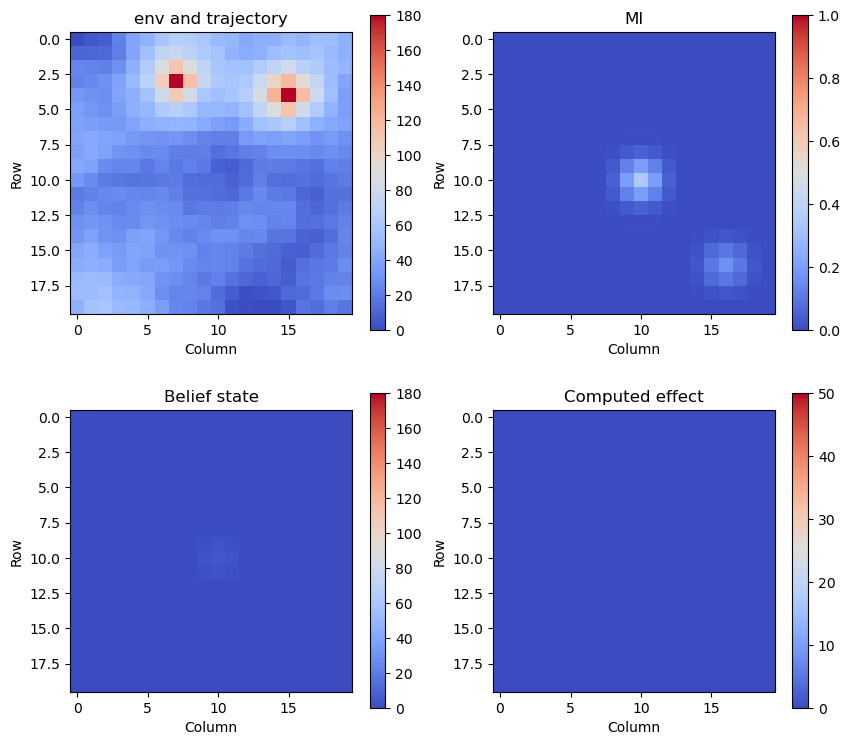

In [9]:
from pypolo2.experiments import visualizer
fig, axs = plt.subplots(2, 2, figsize=(10, 9))
ax1, ax2 = axs[0]
ax3, ax4 = axs[1]

ax1.set_title('env and trajectory')
ax1.set_xlabel('Column')
ax1.set_ylabel('Row')

ax2.set_title('MI')
ax2.set_xlabel('Column')
ax2.set_ylabel('Row')

ax3.set_title('Belief state')
ax3.set_xlabel('Column')
ax3.set_ylabel('Row')

ax4.set_title('Computed effect')
ax4.set_xlabel('Column')
ax4.set_ylabel('Row')

# Set axis limits for both subplots
ax1.axis([-0.5, 19.5, -0.5, 19.5])
ax2.axis([-0.5, 19.5, -0.5, 19.5])
ax3.axis([-0.5, 19.5, -0.5, 19.5])
ax4.axis([-0.5, 19.5, -0.5, 19.5])

# Invert y-axis for both subplots
ax1.invert_yaxis()
ax2.invert_yaxis()
ax3.invert_yaxis()
ax4.invert_yaxis()

# Create heatmap objects for both subplots
heatmap1 = data['truth_env'][0]
heatmap2 = data['MI_information'][0]
heatmap3 = data['observed_env'][0]
heatmap4 = data['computed_effect'][0]

im1 = ax1.imshow(heatmap1, cmap=cm.coolwarm, interpolation='nearest', origin='lower')
im2 = ax2.imshow(heatmap2, cmap=cm.coolwarm, interpolation='nearest', origin='lower')
im3 = ax3.imshow(heatmap3, cmap=cm.coolwarm, interpolation='nearest', origin='lower')
im4 = ax4.imshow(heatmap4, cmap=cm.coolwarm, interpolation='nearest', origin='lower')

# Add colorbars to both subplots
cbar1 = fig.colorbar(im1, ax=ax1)
cbar2 = fig.colorbar(im2, ax=ax2)
cbar3 = fig.colorbar(im3, ax=ax3)
cbar4 = fig.colorbar(im4, ax=ax4)

# Plot the initial trajectory on the third subplot
l_list = []
arr = dict()
for id in range(data['info']['team_size']):
    arr[id+1] = []
for step in range(len(data['time_series'])):
    for id in range(len(data['time_series'][step]['state'])):
        state = data['time_series'][step]['state'][id+1]
        arr[id+1].append(state)
for id in range(data['info']['team_size']):     
    arr[id+1] = np.array(arr[id+1])
    # l, = ax1.plot([],[], color='black', linewidth=1)
    l, = ax1.plot([],[], color='black', linewidth=1 + 0.5*id)
    l_list.append(l)

# Define animate function for both subplots
def animate(i):
    heatmap1 = data['truth_env'][i]
    heatmap2 = data['MI_information'][i]
    heatmap3 = data['observed_env'][i]
    heatmap4 = data['computed_effect'][i]
    
    im1.set_data(heatmap1)
    im2.set_data(heatmap2)
    im3.set_data(heatmap3)
    im4.set_data(heatmap4)
    
    # Adjust the color range of the heatmap
    im1.set_clim(vmin=0, vmax=180)
    im2.set_clim(vmin=0, vmax=1.0)
    im3.set_clim(vmin=0, vmax=180)
    im4.set_clim(vmin=0, vmax=50)
    
    for id in range(data['info']['team_size']):
        traj = arr[id+1]
        # Extract the x-coordinates and y-coordinates up to time i
        x = traj[:i+1, 0]
        y = traj[:i+1, 1]
        # Update the trajectory with the current x and y coordinates
        l_list[id].set_data(y, x)

    return im1, im2, im3, im4, l_list

# Create animation object for both subplots
ani = matplotlib.animation.FuncAnimation(fig, animate, frames = len(data['time_series']))

# Display the animation
from IPython.display import HTML
HTML(ani.to_jshtml())